## Librerías

In [ ]:
from collections import defaultdict

In [1]:
from sklearn.datasets import make_moons, make_blobs

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist

In [4]:
import matplotlib.pyplot as plt

---

## Conjunto de datos 

Se crearan diferentes conjuntos de datos sinteticos que conformaran diferentes clusters, al convinarlos tendremos un unico dataset con diferentes formas de clusters y densidad variables. Esto permite ver fortaleza de HDBSCAN sobre este tipo de agrupaciones.

### Propiedades del dataset

* n = 800
* Dimensión: 2D (ideal para visualizar)

Contiene:

| Tipo           | Dificultad | Qué testea           |
|----------------|------------|----------------------|
| Moons          | Alta       | no convexidad        |
| Blob denso     | Baja       | cluster claro        |
| Blob disperso  | Media      | densidad variable    |
| Ruido          | Alta       | robustez             |

In [5]:
# Reproducibilidad
rng = np.random.RandomState(42)

In [6]:
# 1) Moons (estructura no convexa)
X_moons, _ = make_moons(n_samples=300, noise=0.05)

# 2) Blob denso
X_blob_dense, _ = make_blobs(
    n_samples=200,
    centers=[(2.5, 2.5)],
    cluster_std=0.2,
    random_state=rng
)

# 3) Blob disperso
X_blob_sparse, _ = make_blobs(
    n_samples=200,
    centers=[(-2.5, 2.5)],
    cluster_std=0.7,
    random_state=rng
)

# 4) Ruido uniforme
X_noise = rng.uniform(low=-4, high=4, size=(100, 2))

In [7]:
# Combinar todo
X = np.vstack([
    X_moons,
    X_blob_dense,
    X_blob_sparse,
    X_noise
])

### Visualización

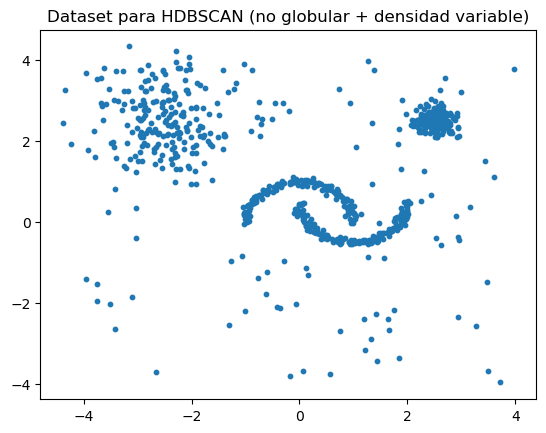

In [8]:
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Dataset para HDBSCAN (no globular + densidad variable)")
plt.show()

---

## Implementación de HDBSCAN paso a paso

### 1. Matriz de distancias $D$

Definición: 

$$D_{ij} = d(x_i, x_j)$$

Propiedades matemáticas:

* No negatividad: $D_{ij} \ge 0$
* Identidad del indiscernible: $D_{ii} = 0$
* Simetría: $D_{ij} = D_{ji}$

In [9]:
def pairwise_distances(X):
    n = X.shape[0]
    D = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(X[i] - X[j])
            D[i, j] = dist
            D[j, i] = dist
            
    return D

In [10]:
D = pairwise_distances(X)

In [11]:
D_check = cdist(X, X, metric='euclidean')

In [12]:
D

array([[0.        , 2.17264723, 2.23321515, ..., 0.82619719, 0.46641588,
        2.6450272 ],
       [2.17264723, 0.        , 0.22388638, ..., 2.53231212, 1.71133261,
        2.82668002],
       [2.23321515, 0.22388638, 0.        , ..., 2.52121779, 1.78214322,
        3.04362662],
       ...,
       [0.82619719, 2.53231212, 2.52121779, ..., 0.        , 1.10082701,
        3.47058349],
       [0.46641588, 1.71133261, 1.78214322, ..., 1.10082701, 0.        ,
        2.47287804],
       [2.6450272 , 2.82668002, 3.04362662, ..., 3.47058349, 2.47287804,
        0.        ]])

In [13]:
D_check

array([[0.        , 2.17264723, 2.23321515, ..., 0.82619719, 0.46641588,
        2.6450272 ],
       [2.17264723, 0.        , 0.22388638, ..., 2.53231212, 1.71133261,
        2.82668002],
       [2.23321515, 0.22388638, 0.        , ..., 2.52121779, 1.78214322,
        3.04362662],
       ...,
       [0.82619719, 2.53231212, 2.52121779, ..., 0.        , 1.10082701,
        3.47058349],
       [0.46641588, 1.71133261, 1.78214322, ..., 1.10082701, 0.        ,
        2.47287804],
       [2.6450272 , 2.82668002, 3.04362662, ..., 3.47058349, 2.47287804,
        0.        ]])

Verificación de propiedades matemáticas


In [14]:
# simetría
np.allclose(D, D.T)

True

In [15]:
# diagonal cero
np.allclose(np.diag(D), 0)

True

In [16]:
# no negatividad

np.all(D >= 0)

True

### 2. Core distance

Definición para cada punto $x_i$:

$$\text{core}_k(x_i) = \text{distancia al } k\text{-ésimo vecino más cercano}$$

donde  $$k = \text{min\_samples}$$


Propiedades matemáticas:

* No negatividad: $c_i \ge 0$
* Consistencia con $D$, para cada $i$: $c_i = \text{k-ésimo valor ordenado de } \{D_{ij}\}_{j \ne i}$
* Monotonicidad en $k$, si $k_1 < k_2$:$ c_i^{(k_1)} \le c_i^{(k_2)}$

In [17]:
def core_distances(D, k):
    n = D.shape[0]
    core = np.zeros(n)
    
    for i in range(n):
        # ordenar distancias (ignorando el 0 a sí mismo)
        sorted_distances = np.sort(D[i])
        
        # índice k porque el primero es 0 (distancia a sí mismo)
        core[i] = sorted_distances[k]
    
    return core

In [18]:
k = 5

In [19]:
core = core_distances(D= D, k=k)

Verificación de propiedades matemáticas


In [20]:
# no negatividad
np.all(core >= 0)

True

In [21]:
# consistencia con D
for i in range(len(core)):
    sorted_d = np.sort(D[i])
    assert np.isclose(core[i], sorted_d[k])

In [22]:
# Monotonicidad en K: 
# verificar que las filas de D estén ordenadas es suficiente, la monotonicidad queda implícitamente garantizada

sorted_D = np.sort(D, axis=1)

# verificar que cada fila esté ordenada
np.all(sorted_D[:, :-1] <= sorted_D[:, 1:])

True

### 3. Mutual reachability distance

Definición clave: 

$$d_{\text{mreach}}(i,j) = \max \left\{
\text{core}(i),\;
\text{core}(j),\;
D_{ij}
\right\}$$


Propiedades matemáticas:

* Simetría: $M_{ij} = M_{ji}$
*  Dominancia $M_{ij} \ge D_{ij}$: $M_{ij} \ge c_i,\quad M_{ij} \ge c_j$
*  No negatividad: $M_{ij} \ge 0$
*  Diagonal: $M_{ii} = \max(c_i, c_i, 0) = c_i$

In [23]:
def mutual_reachability(D, core):
    n = D.shape[0]
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            M[i, j] = max(core[i], core[j], D[i, j])
    
    return M

In [24]:
M = mutual_reachability(D= D, core = core)

In [25]:
M

array([[0.1121655 , 2.17264723, 2.23321515, ..., 0.82619719, 0.46641588,
        2.6450272 ],
       [2.17264723, 0.07540323, 0.22388638, ..., 2.53231212, 1.71133261,
        2.82668002],
       [2.23321515, 0.22388638, 0.10509891, ..., 2.52121779, 1.78214322,
        3.04362662],
       ...,
       [0.82619719, 2.53231212, 2.52121779, ..., 0.07065645, 1.10082701,
        3.47058349],
       [0.46641588, 1.71133261, 1.78214322, ..., 1.10082701, 0.1321215 ,
        2.47287804],
       [2.6450272 , 2.82668002, 3.04362662, ..., 3.47058349, 2.47287804,
        0.11752214]])

Verificación de propiedades matemáticas


In [26]:
# simetría
np.allclose(M, M.T)

True

In [27]:
# dominancia sobre D
np.all(M >= D)

True

In [28]:
# dominancia sobre core
for i in range(len(core)):
    assert np.all(M[i] >= core[i])
    assert np.all(M[:, i] >= core[i])

In [29]:
# diagonal correcta
np.allclose(np.diag(M), core)

True

Mutual reachability convierte el espacio métrico en uno donde
las regiones de baja densidad se vuelven más “lejanas”

Para dos puntos $x_i, x_j$:
- Si ambos están en región densa: $\text{core}(i), \text{core}(j)$ pequeños ⇒ $d_{\text{mreach}} \approx d(x_i, x_j)$
- Si uno está en región dispersa: core grande ⇒ distancia inflada

### 4. MST Prim con mutual reachability on-demand

Definición:

$$\text{MST}(M) \equiv \text{MST usando } d_{\text{mreach}} \text{ on demand}$$ 

Donde: 

$$d_{\text{mreach}} \text{ on demand} = d_{\text{mreach}}(i,j) = \max(c_i, c_j, D_{ij})$$


#### Propiedades estructurales (definen un árbol)
- Número de aristas:|E| = n - 1
- Conectividad: \forall u,v \in V,\; \exists \text{ camino entre } u \text{ y } v
- Acyclicidad: \nexists \text{ ciclos en } T

#### Consistencia con la función de pesos (implementación)

- Para todo $v \neq root$: $key[v] = d_{\text{mreach}}(v, parent[v]) = \max(c_v, c_{parent[v]}, D_{v,parent[v]})$


#### Propiedad de corte (optimalidad local)

- Para toda arista $(u,v) \in T$, al removerla se induce un corte $(A,B)$: $w(u,v) \le w(i,j) \quad \forall i \in A,\; j \in B$

#### Minimalidad global (definición): No verificable directamente, pero garantizada por (3).

- $$T = \arg\min_{T'} \sum_{(i,j)\in T'} w(i,j)$$

In [30]:
def mreach(i, j, D, core):
    return max(core[i], core[j], D[i, j])

In [31]:
def prim_mst(D, core):
    n = len(D)
    
    in_mst = np.zeros(n, dtype=bool)
    key = np.full(n, np.inf)
    parent = np.full(n, -1)
    
    key[0] = 0
    
    for _ in range(n):
        # elegir nodo no incluido con menor key
        u = np.argmin(np.where(in_mst, np.inf, key))
        in_mst[u] = True
        
        for v in range(n):
            if not in_mst[v]:
                weight = mreach(u, v, D, core)
                
                if weight < key[v]:
                    key[v] = weight
                    parent[v] = u
    
    return parent, key

In [32]:
parent, key = prim_mst(D=D, core=core)

* parent[v] → nodo padre de v en el MST
* key[v] → peso de la arista (parent[v], v)

In [33]:
# Número de aristas

assert np.sum(parent != -1) == n - 1

NameError: name 'n' is not defined

In [34]:
# Conectividad

def is_connected(parent):
    n = len(parent)
    adj = [[] for _ in range(n)]
    
    for v in range(n):
        if parent[v] != -1:
            u = parent[v]
            adj[u].append(v)
            adj[v].append(u)
    
    visited = set()
    
    def dfs(u):
        visited.add(u)
        for w in adj[u]:
            if w not in visited:
                dfs(w)
    
    root = np.where(parent == -1)[0][0]
    dfs(root)
    
    return len(visited) == n

assert is_connected(parent)

In [35]:
# Acyclicidad

assert np.sum(parent != -1) == n - 1
assert is_connected(parent)

NameError: name 'n' is not defined

In [36]:
# Consistencia con la función de pesos

for v in range(n):
    if parent[v] != -1:
        assert np.isclose(
            key[v],
            max(core[v], core[parent[v]], D[v, parent[v]])
        )

NameError: name 'n' is not defined

In [ ]:
# Propiedad de corte (optimalidad local)

def check_cut_property(parent, key, D, core):
    n = len(parent)
    
    for v in range(n):
        u = parent[v]
        if u == -1:
            continue
        
        # construir componentes removiendo (u,v)
        adj = [[] for _ in range(n)]
        for i in range(n):
            if parent[i] != -1:
                a, b = i, parent[i]
                if not ((a == v and b == u) or (a == u and b == v)):
                    adj[a].append(b)
                    adj[b].append(a)
        
        # DFS para componente A
        visited = set()
        def dfs(x):
            visited.add(x)
            for y in adj[x]:
                if y not in visited:
                    dfs(y)
        
        dfs(v)
        A = visited
        B = set(range(n)) - A
        
        w_uv = key[v]
        
        # check condición de corte
        for i in A:
            for j in B:
                w_ij = max(core[i], core[j], D[i, j])
                if w_ij < w_uv - 1e-9:
                    return False
    
    return True

assert check_cut_property(parent, key, D, core)

### 5. Single linkage


El clustering jerárquico single linkage define la distancia entre clusters como: $d(A,B) = \min_{i \in A, j \in B} d(i,j)$. En HDBSCAN es distinto, NO usamos distancia euclídea usamos: $d_{\text{mreach}}(i,j)$, y lo más importante el single linkage ya está codificado en el MST; el dendrograma de single linkage dentro de HDBSCAN es equivalente a ordenar las aristas del MST por peso creciente.

Construcción formal del single linkage esta dada por 3 pasos:

1. Extraer aristas del MST: $E = \{(v, parent[v], key[v])\}$
2. Ordenar por peso: $E_{sorted} = \text{sort}(E, \text{por } weight)$
3. Simular merges (Union-Find):  $(u,v)$
4. Construir la jerarquía


#### a. Construir lista de aristas

In [ ]:
def mst_edges(parent, key):
    edges = []
    for v in range(len(parent)):
        if parent[v] != -1:
            edges.append((parent[v], v, key[v]))
    return edges

edges = mst_edges(parent, key)

#### b. Ordenar aristas

In [ ]:
edges_sorted = sorted(edges, key=lambda x: x[2])

#### c. Union-Find

In [ ]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.size = [1] * n
    
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        
        if rx == ry:
            return False
        
        if self.size[rx] < self.size[ry]:
            rx, ry = ry, rx
        
        self.parent[ry] = rx
        self.size[rx] += self.size[ry]
        
        return True

#### d. Construir la jerarquía

In [ ]:
def single_linkage_hierarchy(edges_sorted, n):
    uf = UnionFind(n)
    
    hierarchy = []
    
    for u, v, w in edges_sorted:
        ru, rv = uf.find(u), uf.find(v)
        
        if ru != rv:
            size_u = uf.size[ru]
            size_v = uf.size[rv]
            
            uf.union(ru, rv)
            new_root = uf.find(ru)
            
            hierarchy.append({
                "u": ru,
                "v": rv,
                "weight": w,
                "size": size_u + size_v
            })
    
    return hierarchy

hierarchy = single_linkage_hierarchy(edges_sorted, len(X))

### 6. Condensed tree


La implmentación de condensed tree se basa en reinterpretar la distancia como densidad $\lambda = \frac{1}{d_{\text{mreach}}}$  donde los clusters se dividen al disminuir distancia, ademas se considera algo critico Solo mantendremos clusters donde $\text{tamaño} \ge \text{min\_cluster\_size}$.

La implementación esta compuesta de x pasos:

1. Preparar eventos ordenados por $\lambda$
2. Clusters explicitos
3. Extructuramos el condensed tree
4. Algoritmo principal






#### a. preparar eventos ordenados por λ

In [ ]:
edges_lambda = [
    (u, v, 1.0 / w) for (u, v, w) in edges_sorted
]

# ordenar de mayor λ a menor λ (alta densidad → baja)
edges_lambda = sorted(edges_lambda, key=lambda x: -x[2])

#### b. Identificar clusters explícitos

In [ ]:
clusters = {
    cluster_id: set(points)
}

#### c. Estructura para el condensed tree

In [ ]:
condensed_tree = []

In [ ]:
condensed_tree.append({
    "parent": parent_id,
    "child": cid,
    "lambda_birth": lam,
    "size": size,
    "points": comp   # ← CRÍTICO
})

#### d. Algoritmo principal

In [ ]:
def build_condensed_tree(edges_lambda, n, min_cluster_size):
    # cluster_id -> set de puntos
    clusters = {0: set(range(n))}
    
    # lambda de nacimiento
    birth_lambda = {0: np.inf}
    
    next_cluster_id = 1
    condensed = []
    
    for u, v, lam in edges_lambda:
        
        # encontrar cluster que contiene ambos
        for cid, points in clusters.items():
            if u in points and v in points:
                parent_id = cid
                break
        
        parent_points = clusters[parent_id]
        
        # dividir cluster removiendo la arista (u,v)
        # → necesitamos componentes conectadas
        
        # construir grafo inducido SIN esa arista
        subgraph = {p: set() for p in parent_points}
        
        for a, b, w in edges:
            if (a == u and b == v) or (a == v and b == u):
                continue
            if a in parent_points and b in parent_points:
                subgraph[a].add(b)
                subgraph[b].add(a)
        
        # encontrar componentes conectadas
        visited = set()
        components = []
        
        for p in parent_points:
            if p not in visited:
                stack = [p]
                comp = set()
                
                while stack:
                    x = stack.pop()
                    if x in visited:
                        continue
                    visited.add(x)
                    comp.add(x)
                    stack.extend(subgraph[x])
                
                components.append(comp)
        
        if len(components) <= 1:
            continue
        
        # eliminar cluster padre
        del clusters[parent_id]
        
        # crear hijos
        for comp in components:
            size = len(comp)
            
            if size >= min_cluster_size:
                cid = next_cluster_id
                next_cluster_id += 1
                
                clusters[cid] = comp
                birth_lambda[cid] = lam
                
                condensed.append({
                    "parent": parent_id,
                    "child": cid,
                    "lambda_birth": lam,
                    "size": size
                })
            else:
                # ruido → no se guarda como cluster
                pass
    
    return condensed

#### e. Lambda death

In [ ]:
def compute_lambda_death(condensed):
    # cluster_id -> lambda_death
    death_lambda = {}
    
    # inicializar en 0
    for row in condensed:
        death_lambda[row["child"]] = 0.0
    
    # si un cluster es padre → muere cuando nacen sus hijos
    for row in condensed:
        parent = row["parent"]
        lam = row["lambda_birth"]
        
        if parent not in death_lambda:
            death_lambda[parent] = lam
        else:
            death_lambda[parent] = max(death_lambda[parent], lam)
    
    return death_lambda

### 7. Estabilidad de clusters

HDBSCAN no selecciona clusters por distancia ni por altura del dendrograma, sino por: $\textbf{stability}$

Definición (formal) para un cluster $C$:

$$\text{Stability}(C) = \sum_{x \in C} (\lambda_{\text{death}}(x) - \lambda_{\text{birth}}(C))$$


En nuestro caso utilizaremos una aproximación:

$$\text{Stability}(C) \approx (\lambda_{\text{death}} - \lambda_{\text{birth}}) \cdot |C|$$


Donde para cada punto $x$:
* $\lambda_{\text{birth}}(C)$: cuando el cluster aparece
* $\lambda_{\text{death}}(x)$: cuando el punto abandona el cluster

In [ ]:
def compute_stability(condensed, death_lambda):
    stability = {}
    
    for row in condensed:
        cid = row["child"]
        lam_birth = row["lambda_birth"]
        lam_death = death_lambda.get(cid, 0.0)
        size = row["size"]
        
        stability[cid] = (lam_death - lam_birth) * size
    
    return stability

### 8. Selección de clusters

Defnición:

$$\text{Stability}(C) \ge \sum_{C' \in children(C)} \text{Stability}(C')$$

Se apoya en 2 pasos:

1. construir árbol explícito
2. selección recursiva

#### a. Construir árbol explícito

In [ ]:
def build_tree(condensed):
    children = defaultdict(list)
    
    for row in condensed:
        parent = row["parent"]
        child = row["child"]
        children[parent].append(child)
    
    return children

#### b. Selección recursiva

In [ ]:
def select_clusters(root, children, stability):
    
    def dfs(node):
        if node not in children:
            return stability.get(node, 0), [node]
        
        child_results = [dfs(c) for c in children[node]]
        
        stability_children = sum(r[0] for r in child_results)
        
        if stability.get(node, 0) >= stability_children:
            return stability.get(node, 0), [node]
        else:
            selected = []
            for _, nodes in child_results:
                selected.extend(nodes)
            return stability_children, selected
    
    _, selected_clusters = dfs(root)
    return selected_clusters

### 8. Asignación de labels y detección de ruido

Definición formal:

$$f: x_i \rightarrow \{\text{cluster\_id} \; \cup \; \text{ruido}\}$$

Esta compuesto de x pasos:

1. reconstruir clusters
2.  Asignación de labels y detección de ruidos



#### a. Reconstruir clusters



In [ ]:
def build_cluster_membership(condensed, n):
    clusters = {0: set(range(n))}
    
    for row in condensed:
        parent = row["parent"]
        child = row["child"]
        
        parent_points = clusters[parent]
        
        # dividir puntos (aproximación)
        # en tu implementación ya tenías los componentes
        # → idealmente deberías haberlos guardado
        
        # ⚠️ aquí asumimos que los guardaste
        clusters[child] = row.get("points", set())
    
    return clusters

#### b. Asignación de labels y detección de ruidos

In [ ]:
labels = np.full(n, -1)  # -1 = ruido

In [ ]:
selected_clusters_sorted = sorted(
    selected_clusters,
    key=lambda cid: len(cluster_members[cid])
)

In [ ]:
def assign_labels(selected_clusters, cluster_members, n):
    labels = np.full(n, -1)
    
    # ordenar por tamaño (más pequeños primero)
    ordered = sorted(selected_clusters, key=lambda c: len(cluster_members[c]))
    
    for cluster_id in ordered:
        for p in cluster_members[cluster_id]:
            if labels[p] == -1:
                labels[p] = cluster_id
    
    return labels

---

## Utilizando el modelo

### Entrenamiento

### Ajuste

### Evaluación y visualización

<font color="gray" size="2">

---

© Yané, Ian Cristian Ariel — CC BY-NC 4.0  
Material de autoría original. Uso no comercial. Requiere atribución.  
Ver licencia completa en el repositorio.

</font>